In [1]:
import os
import threading
import time
import pickle
import random

from func_timeout import FunctionTimedOut, func_timeout

import numpy as np
import math
pi = math.pi
tan = math.tan
cos = math.cos
sin = math.sin

from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import queue
import collections.abc 
collections.Iterable=collections.abc.Iterable
import ifc

import ui
from ui.mobility import *
import ui.MarkerDetectionLocalization as mdl

from camera.frame_handler import FrameHandler
from detections.marker_detector import MarkerDetector
import construct

from configs.system_config import *
from configs.construction_config import *

[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image
Robot data listener started on ipc:///tmp/robot.ipc...
Listening for tracking messages...
[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image


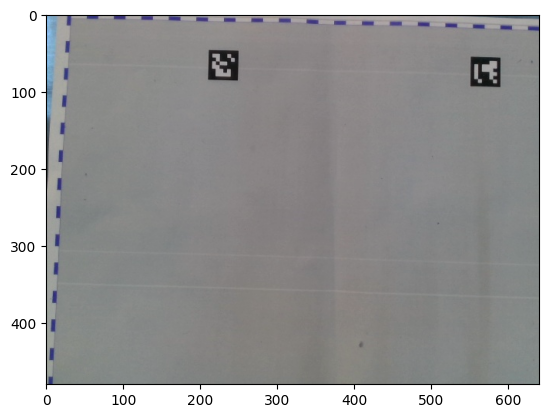

[FrameHandler] WebSocket error: Connection to remote host was lost.
[FrameHandler] WebSocket connection closed.
[FrameHandler] WebSocket error: Connection to remote host was lost.
[FrameHandler] WebSocket connection closed.


In [2]:
framehandler = ui.initializeUI()

In [3]:
# Element = 'Floor_2'

# script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
# IFC_sorted = ifc.IFC_loaded_sorted(*script_args)
# pu_pos, ct_pos, st_pos = construct.scan_site(framehandler,True)

# if Element == 'Foundation':
#     placed_pos = construct.install_Foundation(ct_pos,st_pos,framehandler,MARKER_DICT,IFC_sorted)

# if Element in ['Wall_1', 'Wall_2']:
#     placed_pos = construct.install_Walls(Element, ct_pos, pu_pos, framehandler, MARKER_DICT, IFC_sorted)

# if Element in ['Floor_1','Floor_2']:
#     construct.search_element(Element, framehandler, marker_dict=MARKER_DICT)
#     construct.pick_element(Element,framehandler, pu_pos, marker_dict=MARKER_DICT )
#     construct.swing(ct_pos, Element, "swing")

#     index = (int(Element[-1])*2)
#     place_coords = IFC_sorted[index][1:4]

#     # 5. Place the element
#     placed_pos = construct.place_element(Element, index, place_coords, marker_dict=MARKER_DICT,gripper_rotation =((np.pi)/2))

In [4]:
# # Reconstruct
# Element = 'Floor_2'

# x_offset_wall_place_finetune_2 = 0.005

# script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
# IFC_sorted = ifc.IFC_loaded_sorted(*script_args)
# pu_pos, ct_pos, st_pos = construct.scan_site(framehandler,True)

# if Element == 'Foundation':
#     placed_pos = construct.install_Foundation(ct_pos,st_pos,framehandler,MARKER_DICT,IFC_sorted)

# if Element in ['Wall_1', 'Wall_2']:
#     placed_pos = construct.install_Walls(Element, ct_pos, pu_pos, framehandler, MARKER_DICT, IFC_sorted)

# if Element in ['Floor_1','Floor_2']:
#     construct.search_element(Element, framehandler, marker_dict=MARKER_DICT)
#     construct.pick_element(Element,framehandler, pu_pos, marker_dict=MARKER_DICT )
#     construct.swing(ct_pos, Element, "swing")

#     index = (int(Element[-1])*2)
#     place_coords = IFC_sorted[index][1:4]

#     # 5. Place the element
#     placed_pos = construct.place_element(Element, index, place_coords, marker_dict=MARKER_DICT,gripper_rotation =((np.pi)/2))

In [5]:
##

In [6]:
pu_pos, ct_pos, st_pos = construct.scan_site(framehandler,True)
moveJ(st_pos,ACC, VEL)

# Find and grab block of specified color
red_found, blue_found = construct.check_frame(bathroom_module_color_thresholds, bathroom_module_area_thresholds, framehandler)
print("Red found=", red_found)
print("Blue found=", blue_found)

answer = None# +ve is right
try:
    answer = func_timeout(5, lambda: input('Input color of toilet you want placed [r/b]:\n'))
    print(answer)
except FunctionTimedOut:
    print("Too slow, I will just pick a color for you!")
    answer = None

if answer is None:
    print("Too slow, I will just pick a color for you!")
elif answer == "r" and red_found:
    toilet_pos_grab = construct.grab_toilet(bathroom_module_color_thresholds["red"]["LB"], 
                                  bathroom_module_color_thresholds["red"]["UB"], 
                                  framehandler)
    toilet_found = True
elif answer == "b" and blue_found:
    toilet_pos_grab = construct.grab_toilet(bathroom_module_color_thresholds["blue"]["LB"], 
                                  bathroom_module_color_thresholds["blue"]["UB"], 
                                  framehandler)
    toilet_found = True

Using stub file for site scan
Finished scanning
Red found= False
Blue found= True
b


In [7]:
BM_ID = 3
script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

if BM_ID == 1:
    idx_element = 0
if BM_ID == 2:
    idx_element = 2
if BM_ID == 3:
    idx_element = 4

moveJ(ct_pos, ACC, VEL)

toilet_pos = construct.place_toilet(IFC_sorted, idx_element)

Placing toilet on floor
I am at: [0.5776507880374216, 0.3101850829930573, 0.45199219185752965]
Now, I am at: [0.5644954281139617, 0.298666987239736, 0.45171765783524936]
Ground: 0.09679869150982975 which is z_move(0.32879869150982977) + z_extra(-0.232)


In [9]:
gripper_width(100)

{'status': 'ack', 'result': 'Gripper width set to 100'}

In [8]:
set_orientation(orientations['ct'],ACC, VEL)

current_posj = mdl.get_joints()
current_posj[5] += pi/2
moveJ(current_posj, ACC, VEL)
gripper_width(0)

{'status': 'ack', 'result': 'Gripper width set to 0'}

In [8]:
translate((-0.01,0,0),0.2,0.2)

{'status': 'ack',
 'result': 'translate_tool executed with destination: [[-0.01, 0, 0], 0.2, 0.2]'}

In [23]:
mdl.get_EE_coords()

[0.6347121982824696, 0.20930029362851357, 0.3383943422082999]

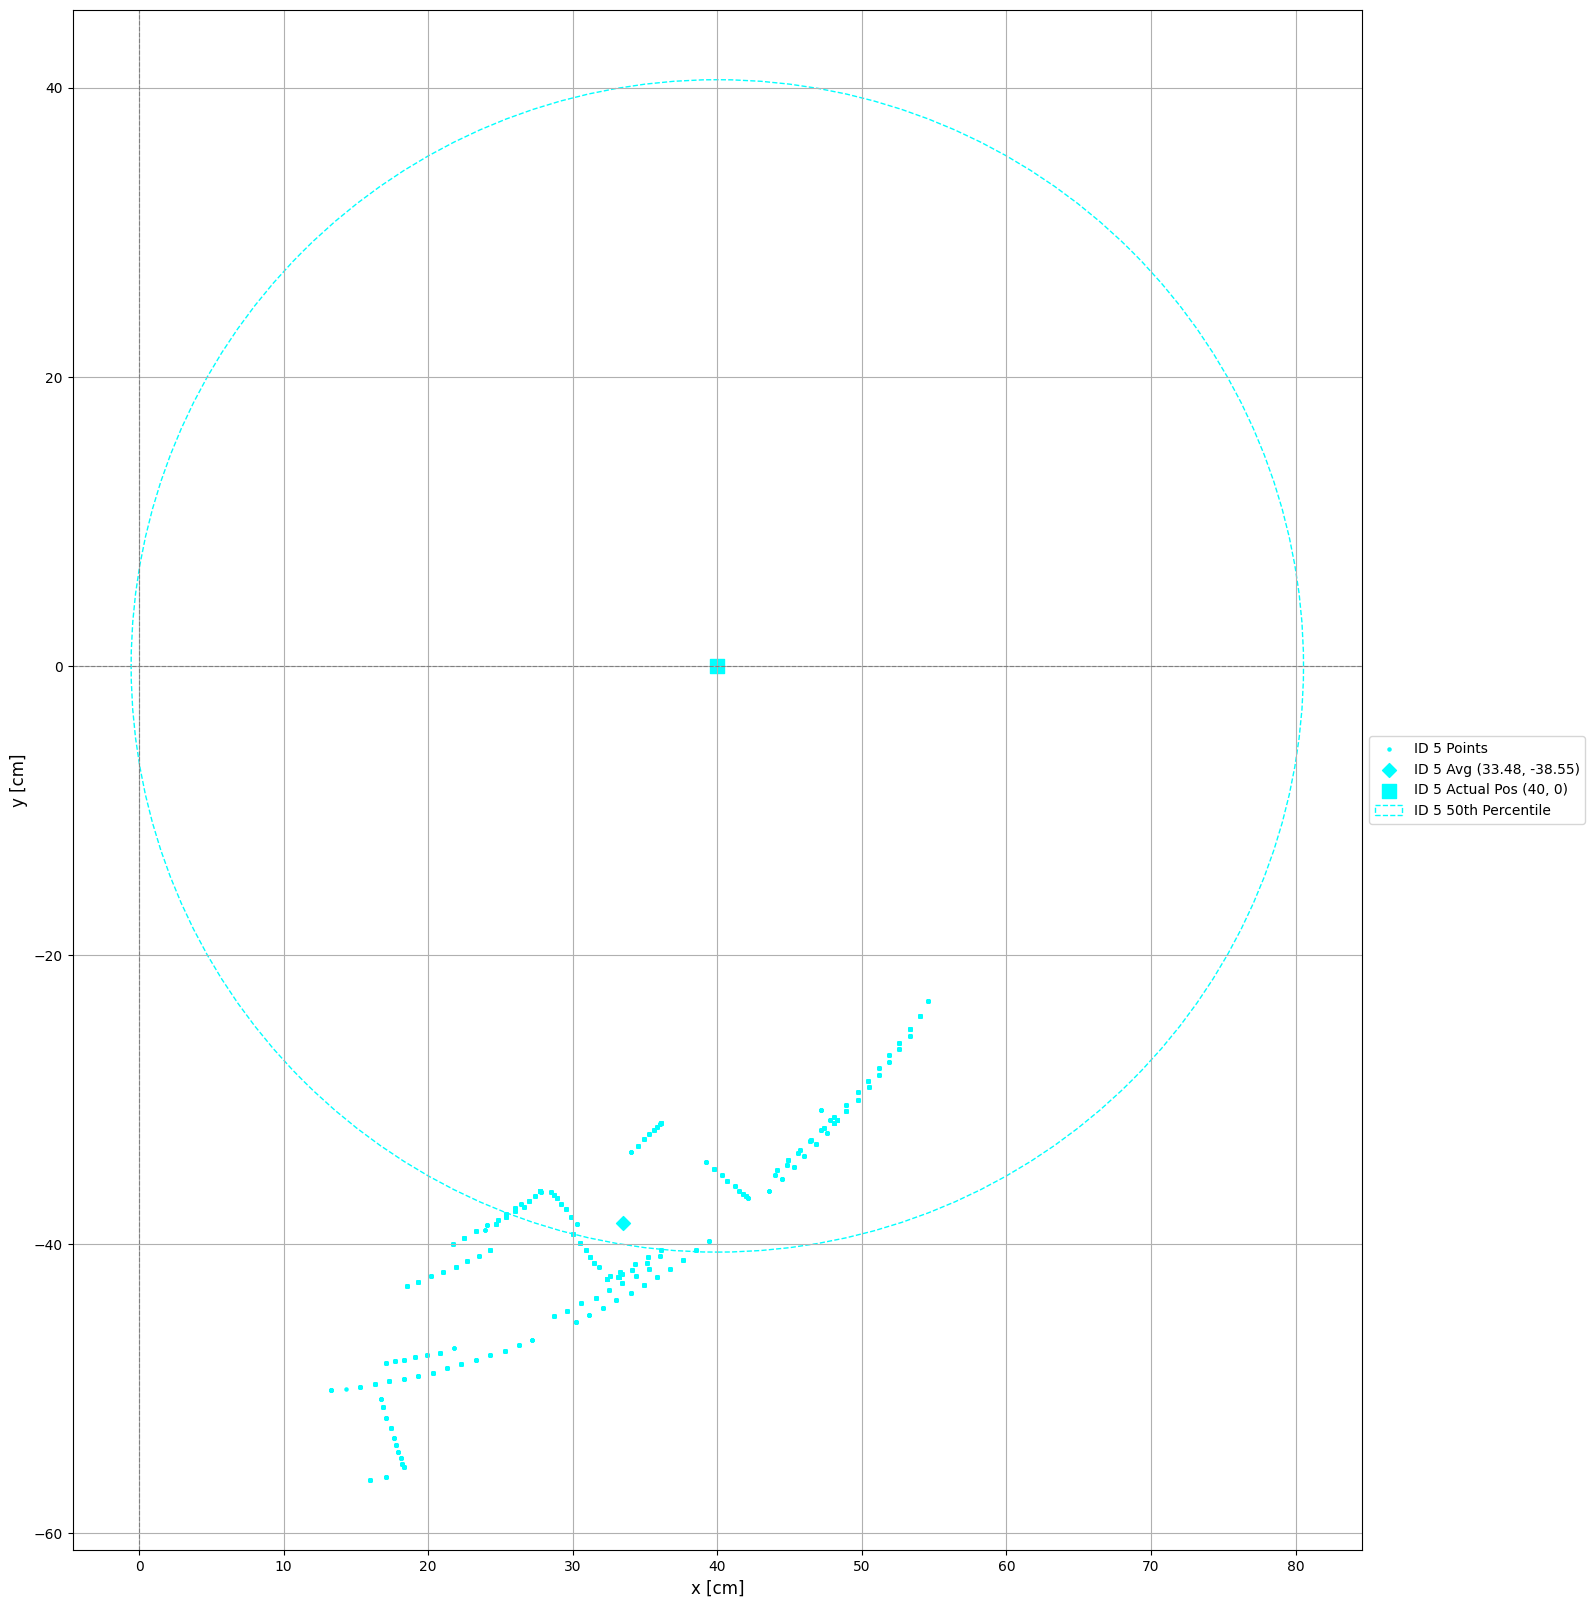

,Aruco ID,True Position X,True Position Y,Radius True,Centroid X,Centroid Y,Radius Centroid,Min Distance X,Min Distance Y,Max Distance X,Max Distance Y
0,5,40,0,40.55,33.48,-38.55,8.02,54.6,-23.2,16.0,-56.3


In [ ]:
from detections import accuracy
import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Load each pickle file
with open(os.path.join(data_dir, 'assembly_data.pkl'), 'rb') as f:
    assembly_data = pickle.load(f)

actual_position = {
    5: (40,0),
    6:(50,-5)
}

test_number = 1
_ = accuracy.CEP50_plot(assembly_data, actual_position,True,False,test_number)
summary_table = accuracy.generate_summary_table(assembly_data, actual_position)
summary_table

In [ ]:
# fov_plotter = analysis.FOVPlotter()
# packet = ui.comms.get_current_packet()
# fov_plotter.plot_camera_fov_at_location(packet['coordinates'][0],packet['coordinates'][1],packet['coordinates'][2],FOV_horizontal,FOV_vertical,90)  